In [ ]:
import sys, subprocess, pkgutil

def _install_if_missing(packages):
    missing = []
    for p in packages:
        import_name = p["import"]
        if pkgutil.find_loader(import_name) is None:
            missing.append(p["pip"])
    if missing:
        print("Installing:", ", ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

_install_if_missing([
    {"pip": "openai", "import": "openai"},
    {"pip": "numpy", "import": "numpy"},
    {"pip": "pandas", "import": "pandas"},
    {"pip": "matplotlib", "import": "matplotlib"},
    {"pip": "networkx", "import": "networkx"},
    {"pip": "scikit-learn", "import": "sklearn"},
])

import os
import json
import math
import textwrap
import random
import getpass
from dataclasses import dataclass
from typing import Dict, List, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from openai import OpenAI

np.random.seed(42)
random.seed(42)

OPENAI_API_KEY = None

try:
    from google.colab import userdata
    OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")
    if OPENAI_API_KEY:
        print("Loaded OPENAI_API_KEY from Colab Secrets.")
except Exception:
    pass

if not OPENAI_API_KEY:
    try:
        OPENAI_API_KEY = getpass.getpass("Enter OPENAI_API_KEY (hidden input): ").strip()
    except Exception:
        OPENAI_API_KEY = input("Enter OPENAI_API_KEY: ").strip()

os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
client = OpenAI(api_key=OPENAI_API_KEY)

OPENAI_MODEL = "gpt-4o-mini"

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def pretty(title: str, body: str, width: int = 100):
    print("\n" + "=" * width)
    print(title)
    print("=" * width)
    print(body)

def safe_float(x):
    try:
        return float(x)
    except Exception:
        return None

def generate_gene_regulatory_network(n_genes: int = 14, edge_prob: float = 0.18):
    genes = [f"G{i+1}" for i in range(n_genes)]
    W = np.zeros((n_genes, n_genes))
    for i in range(n_genes):
        for j in range(n_genes):
            if i != j and np.random.rand() < edge_prob:
                W[i, j] = np.random.uniform(-1.5, 1.5)
    return genes, W

def simulate_gene_expression(W: np.ndarray, n_steps: int = 70, noise: float = 0.10):
    n = W.shape[0]
    X = np.zeros((n_steps, n))
    X[0] = np.random.uniform(0.2, 0.8, size=n)
    for t in range(1, n_steps):
        signal = X[t-1] @ W
        X[t] = sigmoid(signal + np.random.normal(0, noise, size=n))
    return X

def generate_protein_features(n_proteins: int = 40, feature_dim: int = 10):
    proteins = [f"P{i+1}" for i in range(n_proteins)]
    features = np.random.normal(size=(n_proteins, feature_dim))
    families = np.random.randint(0, 5, size=n_proteins)
    localization = np.random.randint(0, 4, size=n_proteins)
    return proteins, features, families, localization

def generate_ppi_dataset(proteins, features, families, localization):
    rows = []
    n = len(proteins)
    hidden_w = np.random.normal(size=features.shape[1])
    for i in range(n):
        for j in range(i + 1, n):
            fi, fj = features[i], features[j]
            sim = np.dot(fi, fj) / (np.linalg.norm(fi) * np.linalg.norm(fj) + 1e-8)
            fam_same = 1 if families[i] == families[j] else 0
            loc_same = 1 if localization[i] == localization[j] else 0
            feat = np.concatenate([
                np.abs(fi - fj),
                fi * fj,
                [sim, fam_same, loc_same]
            ])
            score = 1.4 * sim + 1.0 * fam_same + 0.8 * loc_same + 0.15 * np.dot((fi + fj) / 2, hidden_w)
            prob = sigmoid(score)
            y = 1 if np.random.rand() < prob else 0
            rows.append((proteins[i], proteins[j], feat, y))
    return rows

def generate_metabolic_network():
    metabolites = ["Glucose", "Pyruvate", "AcetylCoA", "ATP", "Biomass", "Lactate", "Ethanol"]
    reactions = [
        {"name": "R1_Glucose_Uptake", "yield_biomass": 0.0, "yield_atp": 0.3, "substrate_cost": 1.0, "oxygen_need": 0.0},
        {"name": "R2_Glycolysis",      "yield_biomass": 0.2, "yield_atp": 1.6, "substrate_cost": 0.7, "oxygen_need": 0.0},
        {"name": "R3_TCA",             "yield_biomass": 1.0, "yield_atp": 2.4, "substrate_cost": 0.8, "oxygen_need": 1.4},
        {"name": "R4_Fermentation",    "yield_biomass": 0.1, "yield_atp": 0.9, "substrate_cost": 0.4, "oxygen_need": 0.0},
        {"name": "R5_Ethanol_Path",    "yield_biomass": 0.15,"yield_atp": 0.8, "substrate_cost": 0.5, "oxygen_need": 0.0},
        {"name": "R6_Biomass_Assembly","yield_biomass": 1.3, "yield_atp": -0.9,"substrate_cost": 0.6, "oxygen_need": 0.2},
    ]
    return metabolites, reactions

def simulate_cell_signaling(T=200, dt=0.05, ligand_level=1.2):
    t = np.arange(0, T * dt, dt)
    ligand = np.ones_like(t) * ligand_level

    receptor = np.zeros_like(t)
    kinase = np.zeros_like(t)
    tf = np.zeros_like(t)
    phosphatase = np.zeros_like(t)

    receptor[0] = 0.05
    kinase[0] = 0.02
    tf[0] = 0.01
    phosphatase[0] = 0.30

    for i in range(1, len(t)):
        dR = 1.6 * ligand[i-1] * (1 - receptor[i-1]) - 0.9 * receptor[i-1]
        dK = 1.8 * receptor[i-1] * (1 - kinase[i-1]) - 1.1 * phosphatase[i-1] * kinase[i-1]
        dTF = 1.4 * kinase[i-1] * (1 - tf[i-1]) - 0.55 * tf[i-1]
        dP = 0.2 + 0.5 * tf[i-1] - 0.4 * phosphatase[i-1]

        receptor[i] = np.clip(receptor[i-1] + dt * dR, 0, 1)
        kinase[i] = np.clip(kinase[i-1] + dt * dK, 0, 1)
        tf[i] = np.clip(tf[i-1] + dt * dTF, 0, 1)
        phosphatase[i] = np.clip(phosphatase[i-1] + dt * dP, 0, 1.5)

    return pd.DataFrame({
        "time": t,
        "ligand": ligand,
        "receptor_active": receptor,
        "kinase_active": kinase,
        "tf_active": tf,
        "phosphatase": phosphatase,
    })

In [ ]:
@dataclass
class AgentResult:
    name: str
    summary: Dict[str, Any]

class GeneRegulatoryNetworkAgent:
    def run(self, genes, W, X) -> AgentResult:
        corr = np.corrcoef(X.T)
        inferred_edges = []
        true_edges = []
        n = len(genes)

        for i in range(n):
            for j in range(n):
                if i == j:
                    continue
                if abs(corr[i, j]) > 0.35:
                    inferred_edges.append((genes[i], genes[j], float(corr[i, j])))
                if abs(W[i, j]) > 1e-8:
                    true_edges.append((genes[i], genes[j], float(W[i, j])))

        centrality_graph = nx.DiGraph()
        for gi in genes:
            centrality_graph.add_node(gi)
        for i in range(n):
            for j in range(n):
                if abs(W[i, j]) > 1e-8:
                    centrality_graph.add_edge(genes[i], genes[j], weight=float(W[i, j]))

        out_deg = dict(centrality_graph.out_degree())
        in_deg = dict(centrality_graph.in_degree())
        hubs = sorted(out_deg.items(), key=lambda x: x[1], reverse=True)[:5]
        sinks = sorted(in_deg.items(), key=lambda x: x[1], reverse=True)[:5]

        dynamic_var = X.var(axis=0)
        most_dynamic = sorted(zip(genes, dynamic_var), key=lambda x: x[1], reverse=True)[:5]

        summary = {
            "num_genes": n,
            "num_true_regulatory_edges": len(true_edges),
            "num_inferred_associations": len(inferred_edges),
            "top_hub_genes": [{"gene": g, "out_degree": int(d)} for g, d in hubs],
            "top_sink_genes": [{"gene": g, "in_degree": int(d)} for g, d in sinks],
            "most_dynamic_genes": [{"gene": g, "variance": round(float(v), 4)} for g, v in most_dynamic],
            "sample_inferred_edges": [
                {"source": a, "target": b, "association": round(c, 3)}
                for a, b, c in inferred_edges[:10]
            ],
            "expression_tail_mean": round(float(X[-10:].mean()), 4),
        }
        return AgentResult(name="GeneRegulatoryNetworkAgent", summary=summary)

In [ ]:
class ProteinInteractionPredictionAgent:
    def run(self, ppi_rows) -> AgentResult:
        X = np.vstack([r[2] for r in ppi_rows])
        y = np.array([r[3] for r in ppi_rows])

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42, stratify=y
        )

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train_s, y_train)
        probs = clf.predict_proba(X_test_s)[:, 1]

        auc = roc_auc_score(y_test, probs)
        ap = average_precision_score(y_test, probs)

        scored_pairs = []
        Xt_full = scaler.transform(X)
        full_probs = clf.predict_proba(Xt_full)[:, 1]
        for (p1, p2, _, label), pr in zip(ppi_rows, full_probs):
            scored_pairs.append((p1, p2, float(pr), int(label)))

        top_candidates = sorted(scored_pairs, key=lambda x: x[2], reverse=True)[:10]
        positive_rate = float(y.mean())

        summary = {
            "num_pairs": int(len(ppi_rows)),
            "positive_interaction_rate": round(positive_rate, 4),
            "test_roc_auc": round(float(auc), 4),
            "test_average_precision": round(float(ap), 4),
            "top_predicted_interactions": [
                {"protein_a": a, "protein_b": b, "pred_prob": round(pr, 4), "label": lab}
                for a, b, pr, lab in top_candidates
            ],
        }
        return AgentResult(name="ProteinInteractionPredictionAgent", summary=summary)

class MetabolicOptimizationAgent:
    def run(self, reactions, oxygen_budget=3.5, substrate_budget=4.0):
        best_score = -1e9
        best_flux = None
        trace = []

        for _ in range(8000):
            flux = np.random.dirichlet(np.ones(len(reactions))) * np.random.uniform(1.5, 5.0)
            oxygen = sum(f["oxygen_need"] * v for f, v in zip(reactions, flux))
            substrate = sum(f["substrate_cost"] * v for f, v in zip(reactions, flux))
            atp = sum(f["yield_atp"] * v for f, v in zip(reactions, flux))
            biomass = sum(f["yield_biomass"] * v for f, v in zip(reactions, flux))

            penalty = 0.0
            if oxygen > oxygen_budget:
                penalty += 6.0 * (oxygen - oxygen_budget)
            if substrate > substrate_budget:
                penalty += 6.0 * (substrate - substrate_budget)

            score = 2.2 * biomass + 0.6 * atp - penalty
            trace.append(score)

            if score > best_score:
                best_score = score
                best_flux = {
                    "oxygen": oxygen,
                    "substrate": substrate,
                    "atp": atp,
                    "biomass": biomass,
                    "fluxes": {reactions[i]["name"]: float(flux[i]) for i in range(len(reactions))}
                }

        ranked_fluxes = sorted(best_flux["fluxes"].items(), key=lambda x: x[1], reverse=True)

        summary = {
            "oxygen_budget": oxygen_budget,
            "substrate_budget": substrate_budget,
            "best_objective_score": round(float(best_score), 4),
            "best_biomass": round(float(best_flux["biomass"]), 4),
            "best_atp": round(float(best_flux["atp"]), 4),
            "oxygen_used": round(float(best_flux["oxygen"]), 4),
            "substrate_used": round(float(best_flux["substrate"]), 4),
            "dominant_reactions": [
                {"reaction": name, "flux": round(val, 4)} for name, val in ranked_fluxes[:6]
            ],
        }
        return AgentResult(name="MetabolicOptimizationAgent", summary=summary), trace

/tmp/ipykernel_2010/3162855002.py:25: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader(import_name) is None:


Enter OPENAI_API_KEY (hidden input): ··········

GeneRegulatoryNetworkAgent
{
  "num_genes": 14,
  "num_true_regulatory_edges": 43,
  "num_inferred_associations": 72,
  "top_hub_genes": [
    {
      "gene": "G5",
      "out_degree": 6
    },
    {
      "gene": "G1",
      "out_degree": 4
    },
    {
      "gene": "G2",
      "out_degree": 4
    },
    {
      "gene": "G3",
      "out_degree": 4
    },
    {
      "gene": "G11",
      "out_degree": 4
    }
  ],
  "top_sink_genes": [
    {
      "gene": "G7",
      "in_degree": 6
    },
    {
      "gene": "G10",
      "in_degree": 6
    },
    {
      "gene": "G12",
      "in_degree": 5
    },
    {
      "gene": "G1",
      "in_degree": 4
    },
    {
      "gene": "G2",
      "in_degree": 4
    }
  ],
  "most_dynamic_genes": [
    {
      "gene": "G6",
      "variance": 0.0023
    },
    {
      "gene": "G10",
      "variance": 0.0022
    },
    {
      "gene": "G4",
      "variance": 0.002
    },
    {
      "gene": "G14",
      "

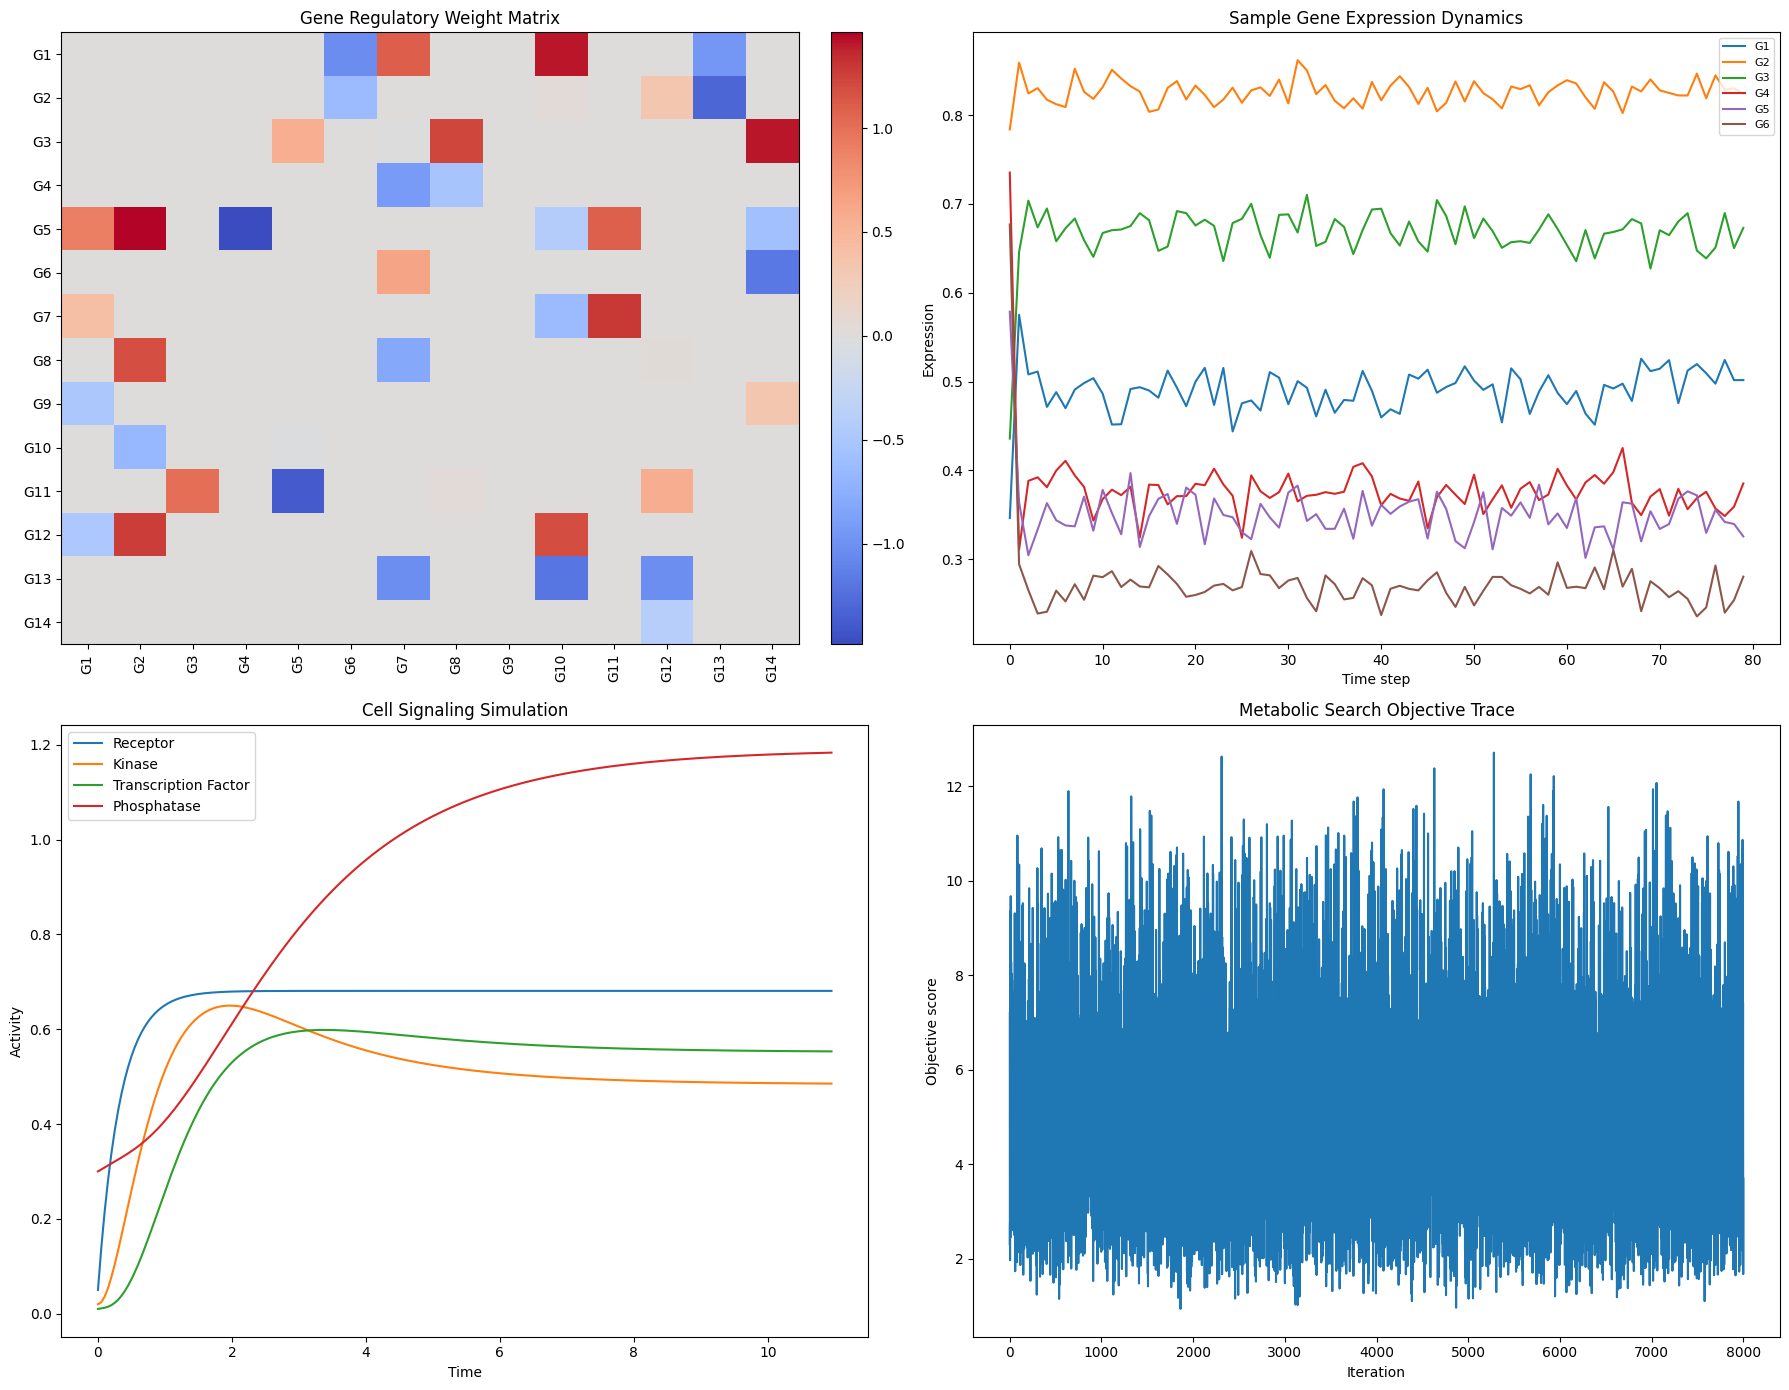

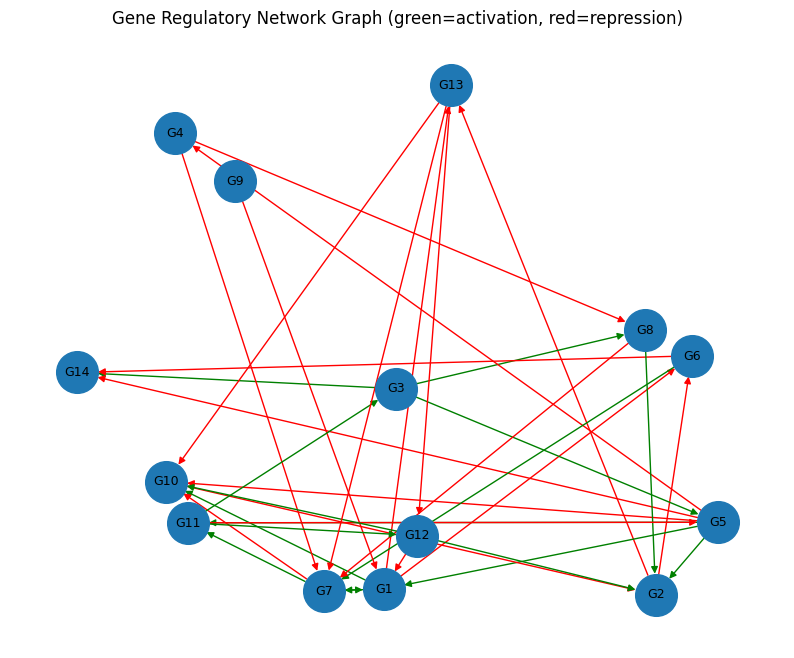

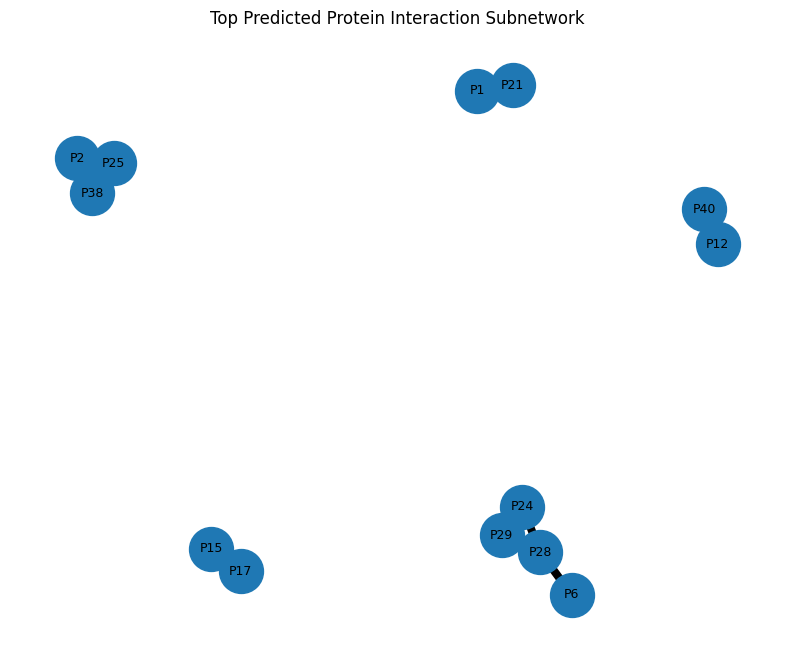


Most Dynamic Genes
gene  variance
  G6    0.0023
 G10    0.0022
  G4    0.0020
 G14    0.0011
  G5    0.0011

Top Predicted PPIs
protein_a protein_b  pred_prob  label
       P2       P25     0.9658      1
      P28       P29     0.9651      1
       P1       P21     0.9636      1
       P6       P28     0.9540      1
      P24       P28     0.9512      1
      P25       P38     0.9504      1
      P24       P29     0.9474      1
      P12       P40     0.9466      1
       P2       P38     0.9464      1
      P15       P17     0.9417      1

Dominant Metabolic Reactions
           reaction   flux
R6_Biomass_Assembly 3.0556
             R3_TCA 1.4454
    R5_Ethanol_Path 0.3508
    R4_Fermentation 0.0745
      R2_Glycolysis 0.0143
  R1_Glucose_Uptake 0.0076

OPENAI SYSTEMS BIOLOGY REPORT
# Report on Integrated Systems Biology Analysis

## Executive Summary
This report synthesizes insights from four specialized AI agents focused on gene regulatory networks, protein interactions, metaboli

In [1]:
class CellSignalingSimulationAgent:
    def run(self, df_signal: pd.DataFrame) -> AgentResult:
        peak_receptor = float(df_signal["receptor_active"].max())
        peak_kinase = float(df_signal["kinase_active"].max())
        peak_tf = float(df_signal["tf_active"].max())

        t_receptor = float(df_signal.loc[df_signal["receptor_active"].idxmax(), "time"])
        t_kinase = float(df_signal.loc[df_signal["kinase_active"].idxmax(), "time"])
        t_tf = float(df_signal.loc[df_signal["tf_active"].idxmax(), "time"])

        final_state = df_signal.iloc[-1].to_dict()

        summary = {
            "peak_receptor_activity": round(peak_receptor, 4),
            "peak_kinase_activity": round(peak_kinase, 4),
            "peak_tf_activity": round(peak_tf, 4),
            "time_to_peak_receptor": round(t_receptor, 4),
            "time_to_peak_kinase": round(t_kinase, 4),
            "time_to_peak_tf": round(t_tf, 4),
            "final_state": {k: round(float(v), 4) for k, v in final_state.items()},
        }
        return AgentResult(name="CellSignalingSimulationAgent", summary=summary)

class PrincipalInvestigatorAgent:
    def __init__(self, client, model=OPENAI_MODEL):
        self.client = client
        self.model = model

    def synthesize(self, results: List[AgentResult]) -> str:
        payload = {r.name: r.summary for r in results}

        prompt = f"""
You are a computational systems biology principal investigator.

Given the outputs of four specialized AI agents:
1. gene regulatory network analysis
2. protein interaction prediction
3. metabolic pathway optimization
4. cell signaling simulation

Write a rigorous but readable report with these sections:
- Executive Summary
- Key Findings by Agent
- Cross-System Biological Interpretation
- Hypotheses Worth Testing in Wet Lab
- Model Limitations
- Next Computational Extensions

Use concise scientific language.
Do not fabricate datasets beyond what is shown.
When useful, connect regulation, signaling, metabolism, and protein interactions into a single systems biology story.

Agent outputs:
{json.dumps(payload, indent=2)}
"""

        try:
            resp = self.client.chat.completions.create(
                model=self.model,
                messages=[
                    {"role": "system", "content": "You are an expert in computational biology, systems biology, and biological network modeling."},
                    {"role": "user", "content": prompt},
                ],
                temperature=0.4,
            )
            return resp.choices[0].message.content
        except Exception as e:
            return f"OpenAI synthesis failed: {e}"

genes, W = generate_gene_regulatory_network(n_genes=14, edge_prob=0.20)
X_expr = simulate_gene_expression(W, n_steps=80, noise=0.08)
grn_agent = GeneRegulatoryNetworkAgent()
grn_result = grn_agent.run(genes, W, X_expr)

proteins, prot_features, prot_families, prot_localization = generate_protein_features(n_proteins=40, feature_dim=10)
ppi_rows = generate_ppi_dataset(proteins, prot_features, prot_families, prot_localization)
ppi_agent = ProteinInteractionPredictionAgent()
ppi_result = ppi_agent.run(ppi_rows)

metabolites, reactions = generate_metabolic_network()
met_agent = MetabolicOptimizationAgent()
met_result, met_trace = met_agent.run(reactions, oxygen_budget=3.5, substrate_budget=4.2)

df_signal = simulate_cell_signaling(T=220, dt=0.05, ligand_level=1.2)
sig_agent = CellSignalingSimulationAgent()
sig_result = sig_agent.run(df_signal)

all_results = [grn_result, ppi_result, met_result, sig_result]

for r in all_results:
    pretty(r.name, json.dumps(r.summary, indent=2))

fig = plt.figure(figsize=(18, 14))

ax1 = plt.subplot(2, 2, 1)
im = ax1.imshow(W, cmap="coolwarm", aspect="auto")
ax1.set_title("Gene Regulatory Weight Matrix")
ax1.set_xticks(range(len(genes)))
ax1.set_yticks(range(len(genes)))
ax1.set_xticklabels(genes, rotation=90)
ax1.set_yticklabels(genes)
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

ax2 = plt.subplot(2, 2, 2)
for i in range(min(6, X_expr.shape[1])):
    ax2.plot(X_expr[:, i], label=genes[i])
ax2.set_title("Sample Gene Expression Dynamics")
ax2.set_xlabel("Time step")
ax2.set_ylabel("Expression")
ax2.legend(loc="upper right", fontsize=8)

ax3 = plt.subplot(2, 2, 3)
ax3.plot(df_signal["time"], df_signal["receptor_active"], label="Receptor")
ax3.plot(df_signal["time"], df_signal["kinase_active"], label="Kinase")
ax3.plot(df_signal["time"], df_signal["tf_active"], label="Transcription Factor")
ax3.plot(df_signal["time"], df_signal["phosphatase"], label="Phosphatase")
ax3.set_title("Cell Signaling Simulation")
ax3.set_xlabel("Time")
ax3.set_ylabel("Activity")
ax3.legend()

ax4 = plt.subplot(2, 2, 4)
ax4.plot(met_trace)
ax4.set_title("Metabolic Search Objective Trace")
ax4.set_xlabel("Iteration")
ax4.set_ylabel("Objective score")

plt.tight_layout()
plt.show()

G_grn = nx.DiGraph()
for g in genes:
    G_grn.add_node(g)
for i in range(len(genes)):
    for j in range(len(genes)):
        if abs(W[i, j]) > 0.4:
            G_grn.add_edge(genes[i], genes[j], weight=W[i, j])

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_grn, seed=42)
edge_colors = ["green" if G_grn[u][v]["weight"] > 0 else "red" for u, v in G_grn.edges()]
nx.draw_networkx(G_grn, pos, with_labels=True, node_size=900, font_size=9, arrows=True, edge_color=edge_colors)
plt.title("Gene Regulatory Network Graph (green=activation, red=repression)")
plt.axis("off")
plt.show()

top_ppi = ppi_result.summary["top_predicted_interactions"][:12]
G_ppi = nx.Graph()
for row in top_ppi:
    a, b, p = row["protein_a"], row["protein_b"], row["pred_prob"]
    G_ppi.add_edge(a, b, weight=p)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_ppi, seed=7)
widths = [2 + 4 * G_ppi[u][v]["weight"] for u, v in G_ppi.edges()]
nx.draw_networkx(G_ppi, pos, with_labels=True, node_size=1000, font_size=9, width=widths)
plt.title("Top Predicted Protein Interaction Subnetwork")
plt.axis("off")
plt.show()

grn_table = pd.DataFrame(grn_result.summary["most_dynamic_genes"])
ppi_table = pd.DataFrame(ppi_result.summary["top_predicted_interactions"])
met_table = pd.DataFrame(met_result.summary["dominant_reactions"])
sig_table = pd.DataFrame([sig_result.summary])

pretty("Most Dynamic Genes", grn_table.to_string(index=False))
pretty("Top Predicted PPIs", ppi_table.to_string(index=False))
pretty("Dominant Metabolic Reactions", met_table.to_string(index=False))

pi_agent = PrincipalInvestigatorAgent(client=client, model=OPENAI_MODEL)
final_report = pi_agent.synthesize(all_results)

pretty("OPENAI SYSTEMS BIOLOGY REPORT", final_report)

artifact = {
    "grn": grn_result.summary,
    "ppi": ppi_result.summary,
    "metabolic": met_result.summary,
    "signaling": sig_result.summary,
    "llm_report": final_report,
}

with open("bio_agents_tutorial_results.json", "w") as f:
    json.dump(artifact, f, indent=2)

print("\nSaved results to: bio_agents_tutorial_results.json")